In [88]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
import pandas as pd
from collections import defaultdict, deque
import matplotlib.patches as patches


In [62]:
raw_data = Table.read('../../ASTRA-DESI-EDR/raw/zone_01.fits.gz')
class_data = Table.read('../../ASTRA-DESI-EDR/classification/zone_01_classified.fits.gz')
pairs_data = Table.read('../../ASTRA-DESI-EDR/pairs/zone_01_pairs.fits.gz')

In [63]:
ii_rand_raw = (raw_data['RANDITER']==0) & (raw_data['TRACERTYPE']=='BGS_ANY_RAND')
ii_data_raw = (raw_data['RANDITER']==-1) & (raw_data['TRACERTYPE']=='BGS_ANY_DATA')

ii_rand_class = (class_data['RANDITER']==0) & (class_data['TRACERTYPE']=='BGS_ANY') & (class_data['ISDATA']==False)
ii_data_class = (class_data['RANDITER']==0) & (class_data['TRACERTYPE']=='BGS_ANY') & (class_data['ISDATA']==True)

ii_pairs = pairs_data['RANDITER']==0


In [64]:
print(np.count_nonzero(ii_rand))
print(np.count_nonzero(ii_data))
print(np.count_nonzero(ii_rand_class))
print(np.count_nonzero(ii_data_class))

13696
13696
13696
13696


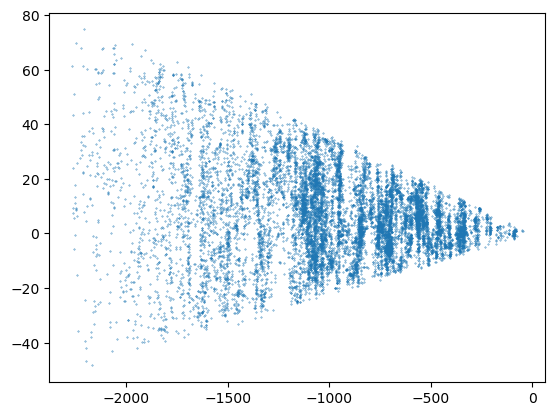

In [65]:
plt.scatter(raw_data['XCART'][ii_data], raw_data['YCART'][ii_data], s=0.1)

In [80]:
raw_table = raw_data[ii_rand_raw][['TARGETID', 'XCART', 'YCART', 'ZCART']]
data_table = raw_data[ii_data_raw][['TARGETID', 'XCART', 'YCART', 'ZCART']]
class_table = class_data[ii_rand_class][['TARGETID', 'NDATA', 'NRAND']]
pairs_table = pairs_data[ii_pairs][['TARGETID1','TARGETID2']]
r_values = (class_table['NDATA']-class_table['NRAND'])/(class_table['NDATA']+class_table['NRAND'])
class_table['R'] = r_values

In [67]:
raw_table

TARGETID,XCART,YCART,ZCART
int64,float64,float64,float64
327858194082695778,-359.6531061661578,5.833492239796129,7.715208158408576
327858139711931270,-914.6810759957439,25.315374658068595,-14.416294984682304
327858188042898140,-975.5016721678589,12.988881861292214,15.496480730350445
327858145781090131,-1996.8445005599272,-5.824494219806081,-28.0853420602118
327858194099473307,-1324.9106487397037,-1.1268049865834555,29.09600209671435
327858200126685574,-1398.8140124247234,15.227828241689117,37.74479984478525
327858163913067150,-1143.5928677756865,-19.855396131117267,0.19509124139644948
327858181998903704,-1522.8463262460277,28.411207797674972,18.3920028212779
327858157860683858,-461.31553136806355,-1.8237783543723654,-1.6119880327757956


In [68]:
class_table

TARGETID,NDATA,NRAND,R
int64,int32,int32,float64
327858194082695778,2,16,-0.7777777777777778
327858139711931270,0,11,-1.0
327858188042898140,6,7,-0.07692307692307693
327858145781090131,7,9,-0.125
327858194099473307,2,12,-0.7142857142857143
327858200126685574,5,8,-0.23076923076923078
327858163913067150,4,7,-0.2727272727272727
327858181998903704,3,11,-0.5714285714285714
327858157860683858,10,11,-0.047619047619047616


In [69]:
pairs_table

TARGETID1,TARGETID2
int64,int64
39627817918402180,327858188030314097
39627817918402180,39627811882796121
39627817918402180,39627817922593467
39627817918402180,39627805838803862
39627817918402180,39627811882796077
39627817918402180,327858188026119468
39627817918402180,327858194074305487
39627817918402180,39627811878600887
39627817918402180,39627817922593828


In [70]:



class WatershedGrouping:
    """
    Watershed algorithm to find groups on a graph based on connectivity and R values.
    
    The algorithm works by:
    1. Starting from points with lowest R values
    2. Assigning points to groups based on connectivity via pairs_table
    3. Only considering points with R <= threshold (default -0.9)
    """
    
    def __init__(self, raw_table, class_table, pairs_table, r_threshold=-0.9):
        """
        Initialize the watershed grouping algorithm.
        
        Parameters:
        -----------
        raw_table : pd.DataFrame
            Table with columns: TARGETID, XCART, YCART, ZCART
        class_table : pd.DataFrame
            Table with columns: TARGETID, NDATA, NRAND, R
        pairs_table : pd.DataFrame
            Table with columns: TARGETID1, TARGETID2 (linked points)
        r_threshold : float
            Maximum R value to consider (default: -0.9)
        """
        self.raw_table = raw_table.copy()
        self.class_table = class_table.copy()
        self.pairs_table = pairs_table.copy()
        self.r_threshold = r_threshold
        
        # Initialize GROUPID column
        self.raw_table['GROUPID'] = -1
        
        # Build adjacency graph from pairs_table
        self.graph = self._build_graph()
        
        # Filter class_table by R threshold and sort by R
        self.filtered_class = self.class_table[
            self.class_table['R'] <= self.r_threshold
        ].sort_values('R').reset_index(drop=True)
        
    def _build_graph(self):
        """Build adjacency list from pairs_table."""
        graph = defaultdict(set)
        
        for _, row in self.pairs_table.iterrows():
            id1 = row['TARGETID1']
            id2 = row['TARGETID2']
            graph[id1].add(id2)
            graph[id2].add(id1)
        
        return graph
    
    def _get_neighbors(self, target_id):
        """Get all neighbors of a given target_id from the graph."""
        return self.graph.get(target_id, set())
    
    def _is_connected_to_group(self, target_id, group_id):
        """Check if a point is connected to any point in the given group."""
        neighbors = self._get_neighbors(target_id)
        
        # Get all points in the specified group
        group_points = set(
            self.raw_table[self.raw_table['GROUPID'] == group_id]['TARGETID'].values
        )
        
        # Check if any neighbor is in the group
        return len(neighbors & group_points) > 0
    
    def _assign_to_existing_or_new_group(self, target_id, current_max_group):
        """
        Assign a point to an existing group if connected, or create a new group.
        
        Returns:
        --------
        int : The new maximum group ID
        """
        # Check connection to existing groups (from 0 to current_max_group)
        for group_id in range(current_max_group + 1):
            if self._is_connected_to_group(target_id, group_id):
                self.raw_table.loc[
                    self.raw_table['TARGETID'] == target_id, 'GROUPID'
                ] = group_id
                return current_max_group
        
        # Not connected to any existing group, create new group
        new_group_id = current_max_group + 1
        self.raw_table.loc[
            self.raw_table['TARGETID'] == target_id, 'GROUPID'
        ] = new_group_id
        return new_group_id
    
    def run(self, verbose=False):
        """
        Run the watershed grouping algorithm.
        
        Parameters:
        -----------
        verbose : bool
            If True, print progress information
        
        Returns:
        --------
        pd.DataFrame : raw_table with GROUPID column added
        """
        if len(self.filtered_class) == 0:
            if verbose:
                print("No points with R <= threshold found.")
            return self.raw_table
        
        current_max_group = -1
        processed_ids = set()
        
        # Group points by R value to handle ties
        r_groups = self.filtered_class.groupby('R')['TARGETID'].apply(list).to_dict()
        sorted_r_values = sorted(r_groups.keys())
        
        if verbose:
            print(f"Processing {len(self.filtered_class)} points with R <= {self.r_threshold}")
        
        for r_value in sorted_r_values:
            # Get all points with this R value
            candidates = r_groups[r_value]
            
            # Shuffle to handle random selection for ties
            np.random.shuffle(candidates)
            
            for target_id in candidates:
                if target_id in processed_ids:
                    continue
                
                if current_max_group == -1:
                    # First point, initialize first group
                    self.raw_table.loc[
                        self.raw_table['TARGETID'] == target_id, 'GROUPID'
                    ] = 0
                    current_max_group = 0
                    if verbose:
                        print(f"Initialized group 0 with point {target_id} (R={r_value:.4f})")
                else:
                    # Assign to existing group or create new group
                    old_max = current_max_group
                    current_max_group = self._assign_to_existing_or_new_group(
                        target_id, current_max_group
                    )
                    
                    if verbose and current_max_group > old_max:
                        assigned_group = self.raw_table[
                            self.raw_table['TARGETID'] == target_id
                        ]['GROUPID'].values[0]
                        print(f"Created new group {assigned_group} with point {target_id} (R={r_value:.4f})")
                
                processed_ids.add(target_id)
        
        if verbose:
            n_groups = len(self.raw_table[self.raw_table['GROUPID'] >= 0]['GROUPID'].unique())
            n_ungrouped = len(self.raw_table[self.raw_table['GROUPID'] == -1])
            print(f"\nGrouping complete:")
            print(f"  Total groups created: {n_groups}")
            print(f"  Points assigned to groups: {len(processed_ids)}")
            print(f"  Points not assigned (GROUPID=-1): {n_ungrouped}")
        
        return self.raw_table

In [106]:
raw_df = raw_table.to_pandas()
class_df = class_table.to_pandas()
pairs_df = pairs_table.to_pandas()
    
# Run watershed algorithm
watershed = WatershedGrouping(raw_df, class_df, pairs_df, r_threshold=-0.8)
result = watershed.run(verbose=True)
    
print("\nResult:")
print(result)

Processing 2443 points with R <= -0.8
Initialized group 0 with point 327858163896289788 (R=-1.0000)
Created new group 1 with point 327858169948669951 (R=-1.0000)
Created new group 2 with point 327858157860685129 (R=-1.0000)
Created new group 3 with point 327858139732902960 (R=-1.0000)
Created new group 4 with point 327858133688912836 (R=-1.0000)
Created new group 5 with point 327858194099470859 (R=-1.0000)
Created new group 6 with point 327858175954913790 (R=-1.0000)
Created new group 7 with point 327858151833470820 (R=-1.0000)
Created new group 8 with point 327858169952862896 (R=-1.0000)
Created new group 9 with point 327858175963301301 (R=-1.0000)
Created new group 10 with point 327858133697299371 (R=-1.0000)
Created new group 11 with point 327858194091084640 (R=-1.0000)
Created new group 12 with point 327858145768507460 (R=-1.0000)
Created new group 13 with point 327858133701495905 (R=-1.0000)
Created new group 14 with point 327858157877461666 (R=-1.0000)
Created new group 15 with p

In [107]:

def compute_group_statistics(result_table, min_group_size=1):
    """
    Compute center of mass and effective radius for each group.
    
    The center of mass is the mean position of all points in the group.
    The effective radius is the RMS (root mean square) distance of points 
    from the center of mass.
    
    Parameters:
    -----------
    result_table : pd.DataFrame
        Output from watershed algorithm with columns:
        TARGETID, XCART, YCART, ZCART, GROUPID
    min_group_size : int
        Minimum number of points required to compute statistics (default: 1)
    
    Returns:
    --------
    pd.DataFrame : Table with columns:
        - GROUPID: Group identifier
        - N_MEMBERS: Number of points in the group
        - XCART_CM: X coordinate of center of mass
        - YCART_CM: Y coordinate of center of mass
        - ZCART_CM: Z coordinate of center of mass
        - R_EFF: Effective radius (RMS distance from center of mass)
    """
    # Filter out ungrouped points (GROUPID = -1)
    grouped_data = result_table[result_table['GROUPID'] >= 0].copy()
    
    if len(grouped_data) == 0:
        print("Warning: No grouped points found!")
        return pd.DataFrame(columns=['GROUPID', 'N_MEMBERS', 'XCART_CM', 
                                     'YCART_CM', 'ZCART_CM', 'R_EFF'])
    
    # Group by GROUPID and compute statistics
    stats_list = []
    
    for group_id in sorted(grouped_data['GROUPID'].unique()):
        group_points = grouped_data[grouped_data['GROUPID'] == group_id]
        n_members = len(group_points)
        
        # Skip if group is too small
        if n_members < min_group_size:
            continue
        
        # Compute center of mass (mean position)
        xcm = group_points['XCART'].mean()
        ycm = group_points['YCART'].mean()
        zcm = group_points['ZCART'].mean()
        
        # Compute effective radius (RMS distance from center of mass)
        dx = group_points['XCART'] - xcm
        dy = group_points['YCART'] - ycm
        dz = group_points['ZCART'] - zcm
        
        r_squared = dx**2 + dy**2 + dz**2
        r_eff = np.sqrt(r_squared.mean())
        
        stats_list.append({
            'GROUPID': group_id,
            'N_MEMBERS': n_members,
            'XCART_CM': xcm,
            'YCART_CM': ycm,
            'ZCART_CM': zcm,
            'R_EFF': r_eff
        })
    
    stats_df = pd.DataFrame(stats_list)
    
    return stats_df


def compute_group_statistics_extended(result_table, class_table=None, min_group_size=1):
    """
    Compute extended statistics for each group including R value statistics.
    
    Parameters:
    -----------
    result_table : pd.DataFrame
        Output from watershed algorithm with GROUPID column
    class_table : pd.DataFrame, optional
        Table with R values for additional statistics
    min_group_size : int
        Minimum number of points required (default: 1)
    
    Returns:
    --------
    pd.DataFrame : Extended statistics table
    """
    # Get basic statistics
    stats_df = compute_group_statistics(result_table, min_group_size)
    
    if class_table is not None:
        # Merge with class_table to get R values
        grouped_data = result_table[result_table['GROUPID'] >= 0].copy()
        merged = grouped_data.merge(class_table[['TARGETID', 'R']], on='TARGETID', how='left')
        
        # Compute R statistics for each group
        r_stats_list = []
        
        for group_id in sorted(merged['GROUPID'].unique()):
            group_r = merged[merged['GROUPID'] == group_id]['R']
            
            if len(group_r) >= min_group_size:
                r_stats_list.append({
                    'GROUPID': group_id,
                    'R_MIN': group_r.min(),
                    'R_MAX': group_r.max(),
                    'R_MEAN': group_r.mean(),
                    'R_MEDIAN': group_r.median(),
                    'R_STD': group_r.std()
                })
        
        r_stats_df = pd.DataFrame(r_stats_list)
        
        # Merge with basic statistics
        stats_df = stats_df.merge(r_stats_df, on='GROUPID', how='left')
    
    return stats_df



def print_group_summary(stats_df):
    """
    Print a formatted summary of group statistics.
    
    Parameters:
    -----------
    stats_df : pd.DataFrame
        Output from compute_group_statistics
    """
    print("=" * 80)
    print("GROUP STATISTICS SUMMARY")
    print("=" * 80)
    print(f"\nTotal number of groups: {len(stats_df)}")
    
    if len(stats_df) > 0:
        print(f"\nGroup size statistics:")
        print(f"  Total members across all groups: {stats_df['N_MEMBERS'].sum()}")
        print(f"  Min group size: {stats_df['N_MEMBERS'].min()}")
        print(f"  Max group size: {stats_df['N_MEMBERS'].max()}")
        print(f"  Mean group size: {stats_df['N_MEMBERS'].mean():.2f}")
        print(f"  Median group size: {stats_df['N_MEMBERS'].median():.2f}")
        
        print(f"\nEffective radius statistics:")
        print(f"  Min R_EFF: {stats_df['R_EFF'].min():.4f}")
        print(f"  Max R_EFF: {stats_df['R_EFF'].max():.4f}")
        print(f"  Mean R_EFF: {stats_df['R_EFF'].mean():.4f}")
        print(f"  Median R_EFF: {stats_df['R_EFF'].median():.4f}")
        
        print(f"\n{'Top 10 largest groups:':}")
        print("-" * 80)
        top_groups = stats_df.nlargest(10, 'N_MEMBERS')
        print(top_groups[['GROUPID', 'N_MEMBERS', 'R_EFF']].to_string(index=False))
        
        if 'R_MEAN' in stats_df.columns:
            print(f"\nR value statistics:")
            print(f"  Min R_MEAN: {stats_df['R_MEAN'].min():.6f}")
            print(f"  Max R_MEAN: {stats_df['R_MEAN'].max():.6f}")
    
    print("\n" + "=" * 80)


# Compute statistics
stats = compute_group_statistics_extended(result, class_df)

# View results
print(stats)


     GROUPID  N_MEMBERS     XCART_CM   YCART_CM   ZCART_CM       R_EFF  R_MIN  \
0          0        377  -777.160519   0.159014   2.784071  402.331688   -1.0   
1          1         35 -1247.032080  -9.445595   5.736016  192.286199   -1.0   
2          2         67 -1152.531877   4.207460 -14.947045  198.489285   -1.0   
3          3         67  -689.386776   2.020466  -5.462151  506.460451   -1.0   
4          4         17  -501.383325   0.882426  -9.462464  229.885022   -1.0   
..       ...        ...          ...        ...        ...         ...    ...   
299      299          1 -1479.445359   7.371410   2.098661    0.000000   -0.8   
300      300          1  -963.516556  14.257811  -4.242980    0.000000   -0.8   
301      301          1  -778.511771   0.123930 -12.983368    0.000000   -0.8   
302      302          1 -1440.823495  36.059073  -8.140501    0.000000   -0.8   
303      303          1  -524.947855  -3.085264 -13.641315    0.000000   -0.8   

        R_MAX    R_MEAN  R_

(-965.8101408126973, 1027.2880337880686)

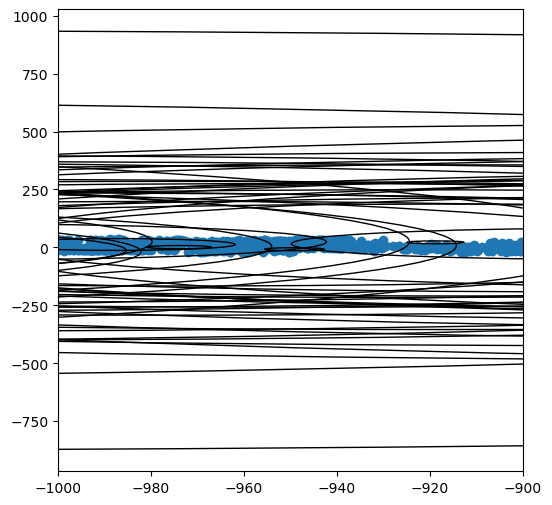

In [108]:
#plt.scatter(result['XCART'][ii], result['YCART'][ii])
fig, ax = plt.subplots(figsize=(6,6))

plt.scatter(data_table['XCART'], data_table['YCART'])

for idx, row in stats.iterrows():
    group_id = row['GROUPID']
    if row['R_EFF']>5.0:
        circle = patches.Circle((row['XCART_CM'], row['YCART_CM']), row['R_EFF'], fill=False)
        ax.add_patch(circle)

plt.xlim((-1000,-900))
plt.ylim()

67


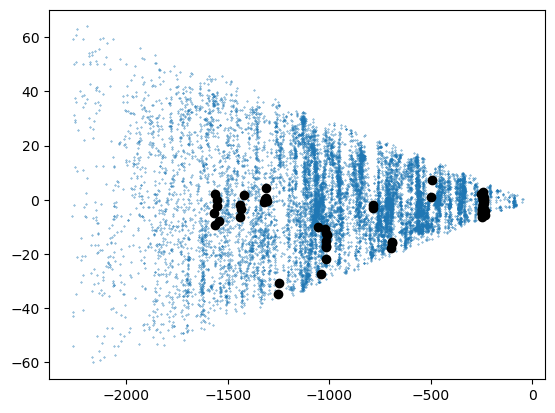

In [124]:
ll = result['GROUPID']==3
print(np.count_nonzero(ll))
plt.scatter(data_table['XCART'], data_table['ZCART'], s=0.1)
#plt.scatter(stats['XCART_CM'], stats['YCART_CM'])
plt.scatter(result['XCART'][ll], result['ZCART'][ll], color='black')
#plt.xlim((-800,-700))


In [112]:
result

,TARGETID,XCART,YCART,ZCART,GROUPID
0,327858194082695778,-359.653106,5.833492,7.715208,-1
1,327858139711931270,-914.681076,25.315375,-14.416295,185
2,327858188042898140,-975.501672,12.988882,15.496481,-1
3,327858145781090131,-1996.844501,-5.824494,-28.085342,-1
4,327858194099473307,-1324.910649,-1.126805,29.096002,-1
...,...,...,...,...,...
13691,327858151804109193,-1240.868808,20.000089,-11.807295,2
13692,327858145793672060,-444.283295,-7.173080,-5.340309,-1
13693,327858163892093631,-1451.594612,8.566434,0.179255,0
13694,327858169948670429,-1105.708837,-10.411211,6.073866,-1


(-1000.0, -900.0)

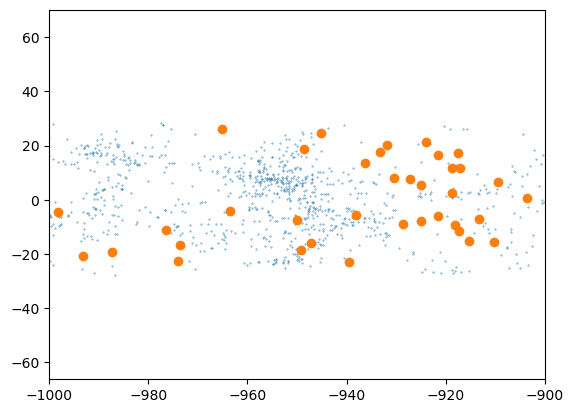

In [110]:
plt.scatter(data_table['XCART'], data_table['ZCART'], s=0.1)
plt.scatter(stats['XCART_CM'], stats['ZCART_CM'])
plt.xlim((-1000,-900))
